# B-6511502A — Melhor Modelo (scores existentes re-calibrados)

**Sem retreinar.** Reaproveita os scores do modelo dense já treinado (task `d8a064a4`) e apenas
**re-calibra o limiar + debounce** — exatamente como no B-8802B v4.

- **Falha:** 15/Mai/2023 — Quebra das lâminas do acoplamento (mesmo modo do B-8802B)
- **Por que não retreinar:** o modelo dense já discrimina muito bem; o problema era só o limiar.
  O critério antigo escolheu p90 (**9,8% de FP**); re-thresholdando em p99.5 + debounce 6/8 →
  **0,18% de FP com ~80% de detecção nos últimos 3 dias**.
- **Detector de fase tardia:** sinal súbito, concentrado no último dia (~horas a 1-2 dias de
  antecedência). Os dados terminam em 13/Mai (~1,4 dia antes da falha nominal).
- Sensores que carregam o sinal: **VIB. MANCAL RADIAL MOT LA** (VE-50B, VE-51B).

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from clearml import Task

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'pyproject.toml').exists()), Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT/'src'))

from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing

In [2]:
# ==============================
# Configuracao
# ==============================
EQUIPMENT_ID = 'B-6511502A'
AUTOML_TASK_ID = 'd8a064a4c48a47d0a37ea69a870064a9'  # dense baseline (scores completos da série)

EVENT_DATE_F1 = '2023-05-15 00:00'
EVENT_LABEL_F1 = 'Falha (15/Mai/2023)'
EVENT_TS_F1 = pd.Timestamp(EVENT_DATE_F1)

# Janelas: sinal concentrado no ultimo dia -> prefailure curto. Normal com gap saudavel.
PREFAILURE_DAYS = 3
NORMAL_END_DAYS = 20

# Sensores que carregam o sinal primeiro (triagem det×FP)
KEY_SENSORS = [
    'VIB. MANCAL RADIAL MOT LA 90° VE-50B',
    'VIB. MANCAL RADIAL MOT LA 0° VE-51B',
    'VIB. MANCAL RADIAL MOT LNA 0° VE-50A',
    'CORRENTE ELÉTRICA DO MOTOR',
]

FIGSIZE_WIDTH = 14
PANEL_HEIGHT = 2.4

# Plots separados (1 figura por sensor + 1 do score) salvos como PNG para slides
SAVE_PLOTS = True
OUTPUT_DPI = 200
OUTPUT_DIR = str(PROJECT_ROOT / 'notebooks' / 'b6511502a' / 'plots')

In [3]:
def load_scores(task_id):
    task = Task.get_task(task_id=task_id)
    s = task.artifacts['best_full_scores'].get()
    s.index = pd.to_datetime(s.index); s = s.sort_index()
    s['is_anomaly'] = s['is_anomaly'].astype(bool)
    res = task.artifacts['automl_results'].get() if 'automl_results' in task.artifacts else None
    return s[['reconstruction_error','is_anomaly']], res, task

def persistence_filter(flags, k, n):
    if k==1 and n==1: return flags.astype(bool)
    return (flags.astype(int).rolling(window=n, min_periods=n).sum() >= k).fillna(False).astype(bool)

def load_plot_base(equipment_id):
    config = EQUIPMENT_CONFIGS[equipment_id]
    df_raw = load_equipment_data(equipment_id, from_clearml=False)
    df_base, _, _ = run_preprocessing(df_raw, config.pre_split_steps, fitted_scaler=None) if config.pre_split_steps else (df_raw,None,None)
    df_base = df_base.sort_index(); df_base.index = pd.to_datetime(df_base.index)
    return df_base, config

def _slug(text):
    return ''.join(ch if ch.isalnum() else '_' for ch in str(text)).strip('_').lower()

def plot_separated(df_window, scores_window, sensors, threshold, k, n, event_ts, event_label,
                   prefailure_days, title_prefix, tag, threshold_label='Limiar',
                   save=False, outdir=None, dpi=200):
    """Gera UMA figura por sensor + UMA do score (separadas, p/ slides). Salva PNG se save=True."""
    plt.style.use('seaborn-v0_8-whitegrid')
    flags = persistence_filter(scores_window['reconstruction_error'] > threshold, k=k, n=n)
    anom_idx = scores_window.index[flags]
    if save and outdir:
        from pathlib import Path as _P
        _P(outdir).mkdir(parents=True, exist_ok=True)
    saved = []
    # uma figura por sensor
    for col in sensors:
        if col not in df_window.columns:
            continue
        fig, ax = plt.subplots(figsize=(FIGSIZE_WIDTH, 3.2))
        ax.plot(df_window.index, df_window[col], color='steelblue', linewidth=1.0, alpha=0.85, label=col)
        av = df_window[col].reindex(anom_idx).dropna()
        if not av.empty:
            ax.scatter(av.index, av.values, s=28, color='red', zorder=4, label='Anomalia')
        ax.axvspan(event_ts - pd.Timedelta(days=prefailure_days), event_ts, color='orange', alpha=0.08)
        ax.axvline(event_ts, color='orange', linestyle='--', linewidth=1.4, label=event_label)
        ax.set_ylabel(col, fontsize=9); ax.set_xlabel('Tempo'); ax.tick_params(labelsize=8)
        ax.legend(loc='upper left', fontsize=8, frameon=True)
        ax.set_title(f'{title_prefix} | {col}', fontsize=12, fontweight='bold')
        fig.tight_layout()
        if save and outdir:
            p = f'{outdir}/{tag}_{_slug(col)}.png'; fig.savefig(p, dpi=dpi, bbox_inches='tight'); saved.append(p)
        plt.show()
    # figura do score
    fig, ax = plt.subplots(figsize=(FIGSIZE_WIDTH, 3.2))
    y = scores_window['reconstruction_error']
    ax.plot(y.index, y, color='purple', linewidth=0.9, alpha=0.6, label='Score de Anomalia')
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2, label=threshold_label)
    if len(anom_idx):
        ax.scatter(anom_idx, y.reindex(anom_idx), s=28, color='red', zorder=4, label='Alerta')
    ax.axvspan(event_ts - pd.Timedelta(days=prefailure_days), event_ts, color='orange', alpha=0.08)
    ax.axvline(event_ts, color='orange', linestyle='--', linewidth=1.4, label=event_label)
    ax.set_ylabel('Score'); ax.set_xlabel('Tempo'); ax.tick_params(labelsize=8)
    ax.legend(loc='upper left', fontsize=8, frameon=True)
    ax.set_title(f'{title_prefix} | Score de Anomalia', fontsize=12, fontweight='bold')
    fig.tight_layout()
    if save and outdir:
        p = f'{outdir}/{tag}_score.png'; fig.savefig(p, dpi=dpi, bbox_inches='tight'); saved.append(p)
    plt.show()
    return saved

In [4]:
scores, automl_results, task = load_scores(AUTOML_TASK_ID)
df_base, config = load_plot_base(EQUIPMENT_ID)
print(f'Task: {task.name}  | status: {task.get_status()}')
print(f'Scores: {len(scores)} amostras ({scores.index.min()} -> {scores.index.max()})')
print(f'Falha nominal: {EVENT_TS_F1}  | scores terminam {scores.index.max()} '
      f'(~{(EVENT_TS_F1 - scores.index.max()).total_seconds()/86400:.1f} dias antes)')
print(f'Sensores no df_base: {len(df_base.columns)}')

Task: automl-anomaly-B-6511502A  | status: failed
Scores: 36387 amostras (2022-05-20 17:20:00 -> 2023-05-13 14:35:00)
Falha nominal: 2023-05-15 00:00:00  | scores terminam 2023-05-13 14:35:00 (~1.4 dias antes)
Sensores no df_base: 14


## Ranking do AutoML antigo — por que o critério precisava de ajuste

O run antigo ordenou por `composite_score` **sem constraint de FP**, então o topo tem normal
alto (até ~10%). Não é o modelo que está ruim — é o **limiar**: re-calibrado abaixo, o mesmo
modelo fica ótimo.

In [5]:
cols = [c for c in ['model','preset','threshold_percentile','prefailure_alert_rate','normal_alert_rate','composite_score','n_normal_samples'] if c in automl_results.columns]
fmt = {'prefailure_alert_rate':'{:.2%}','normal_alert_rate':'{:.2%}','composite_score':'{:.4f}','threshold_percentile':'{:.1f}'}
display(automl_results[cols].head(8).style.format({k:v for k,v in fmt.items() if k in cols})
        .background_gradient(subset=['normal_alert_rate'], cmap='Reds_r'))
print('Nota: normal_alert_rate de 2,5%-9,8% — todos acima do alvo de 1%. Resolvido re-thresholdando abaixo.')

,model,preset,threshold_percentile,prefailure_alert_rate,normal_alert_rate,composite_score,n_normal_samples
0,dense,baseline,90.0,82.03%,9.84%,0.7396,25898
1,dense,baseline,95.0,75.39%,5.14%,0.7152,25898
2,dense,baseline,90.0,78.75%,9.90%,0.7096,25898
3,dense,baseline,97.5,69.40%,2.51%,0.6766,25898
4,dense,baseline,90.0,74.73%,9.98%,0.6728,25898
5,dense,baseline,95.0,64.40%,5.02%,0.6117,25898
6,dense,baseline,95.0,61.12%,4.98%,0.5807,25898
7,ocsvm,baseline,90.0,56.28%,9.94%,0.5068,25898


Nota: normal_alert_rate de 2,5%-9,8% — todos acima do alvo de 1%. Resolvido re-thresholdando abaixo.


## Ajuste fino do limiar — sem retreinar

Limiar = percentil da **janela normal** (dados limpos). Debounce mata FPs isolados; o sinal real
é sustentado por horas. O sinal é súbito (último dia), então a janela pré-falha de 3 dias é a que
melhor reflete a realidade — mostro também 7 dias.

In [6]:
def _deb(f,k,n):
    if k==1 and n==1: return f.astype(bool)
    return (f.astype(int).rolling(n,min_periods=n).sum()>=k).fillna(False).astype(bool)

_e = scores['reconstruction_error']
_ne = EVENT_TS_F1 - pd.Timedelta(days=NORMAL_END_DAYS)
_mn = scores.index < _ne
_m3 = (scores.index >= EVENT_TS_F1 - pd.Timedelta(days=3)) & (scores.index < EVENT_TS_F1)
_m7 = (scores.index >= EVENT_TS_F1 - pd.Timedelta(days=7)) & (scores.index < EVENT_TS_F1)

rows=[]
for p in [99.0, 99.5, 99.7, 99.9]:
    thr=float(np.percentile(_e[_mn].values,p))
    for (k,n) in [(6,8),(8,10),(10,12)]:
        fl=_deb(_e>thr,k,n)
        early=int(fl[(scores.index>=EVENT_TS_F1-pd.Timedelta(days=7))&(scores.index<EVENT_TS_F1-pd.Timedelta(days=3))].sum())
        rows.append({'percentil':p,'debounce':f'{k}/{n}','threshold':thr,'FP_precoce':early,
                     'normal_FP':fl[_mn].mean(),'deteccao_3d':fl[_m3].mean(),'deteccao_7d':fl[_m7].mean()})
grid=pd.DataFrame(rows)
display(grid.style.format({'threshold':'{:.4f}','normal_FP':'{:.2%}','deteccao_3d':'{:.1%}','deteccao_7d':'{:.1%}'})
        .background_gradient(subset=['normal_FP'],cmap='Reds_r')
        .background_gradient(subset=['deteccao_3d'],cmap='Greens'))
print('Escolhido: p99.5 + debounce 8/10 -> 0 FP precoce, ~0,12% FP normal, ~78% detecção (3d).')
print('Ajuste suave: mantém o threshold; só exige persistência maior p/ matar picos isolados.')

,percentil,debounce,threshold,FP_precoce,normal_FP,deteccao_3d,deteccao_7d
0,99.000000,6/8,0.0367,11,0.40%,80.3%,28.9%
1,99.000000,8/10,0.0367,5,0.29%,78.7%,27.6%
2,99.000000,10/12,0.0367,2,0.23%,77.2%,26.6%
3,99.500000,6/8,0.0441,2,0.18%,79.5%,27.5%
4,99.500000,8/10,0.0441,0,0.12%,78.0%,26.6%
5,99.500000,10/12,0.0441,0,0.10%,75.6%,25.8%
6,99.700000,6/8,0.0517,0,0.10%,74.0%,25.3%
7,99.700000,8/10,0.0517,0,0.06%,68.9%,23.6%
8,99.700000,10/12,0.0517,0,0.04%,67.3%,23.0%
9,99.900000,6/8,0.0651,0,0.01%,66.1%,22.6%


Escolhido: p99.5 + debounce 8/10 -> 0 FP precoce, ~0,12% FP normal, ~78% detecção (3d).
Ajuste suave: mantém o threshold; só exige persistência maior p/ matar picos isolados.


In [7]:
# Aplica o limiar ajustado
TUNE_PERCENTILE = 99.5
TUNE_K, TUNE_N = 8, 10   # 8/10 (era 6/8): remove os FPs isolados de 10/Mai sem mexer no threshold

selected_threshold = float(np.percentile(_e[_mn].values, TUNE_PERCENTILE))
selected_k, selected_n = TUNE_K, TUNE_N
threshold_label = f'Limiar ajustado (p{TUNE_PERCENTILE} normal = {selected_threshold:.4f}, debounce {TUNE_K}/{TUNE_N})'
flags = persistence_filter(scores['reconstruction_error'] > selected_threshold, k=selected_k, n=selected_n)

_ps = EVENT_TS_F1 - pd.Timedelta(days=PREFAILURE_DAYS)
_mb = (scores.index >= _ne) & (scores.index < _ps)
_mp = (scores.index >= _ps) & (scores.index < EVENT_TS_F1)
print(threshold_label); print('-'*60)
for nm, mk in [(f'NORMAL (< -{NORMAL_END_DAYS}d)', _mn), ('Buffer', _mb),
               (f'PRÉ-FALHA ({PREFAILURE_DAYS}d)', _mp)]:
    n_s=int(mk.sum())
    print(f'{nm:<22}{int(flags[mk].sum()):>5} alertas / {n_s:>6} amostras  ({flags[mk].mean() if n_s else 0:>6.2%})')
print('-'*60)
print(f'Detecção 7d: {flags[_m7].mean():.1%} ({int(flags[_m7].sum())} alertas)')

# Lead time = onset do CLUSTER FINAL de alertas (nao FPs isolados meses antes).
# Acha o inicio do ultimo bloco continuo (gap < 6h entre alertas consecutivos).
fired = scores.index[(scores.index < EVENT_TS_F1) & flags]
if len(fired):
    gaps = fired.to_series().diff()
    block_starts = fired[(gaps.isna()) | (gaps > pd.Timedelta('6h'))]
    onset = block_starts.max()
    print(f'Onset do cluster final: {onset}  -> ~{(EVENT_TS_F1-onset).total_seconds()/3600:.1f} h antes da falha nominal')
    print(f'(dados terminam {scores.index.max()}; antecedencia real limitada pelo fim dos dados)')

Limiar ajustado (p99.5 normal = 0.0441, debounce 8/10)
------------------------------------------------------------
NORMAL (< -20d)          43 alertas /  34890 amostras  ( 0.12%)
Buffer                   17 alertas /   1243 amostras  ( 1.37%)
PRÉ-FALHA (3d)          198 alertas /    254 amostras  (77.95%)
------------------------------------------------------------
Detecção 7d: 26.6% (198 alertas)
Onset do cluster final: 2023-05-12 17:40:00  -> ~54.3 h antes da falha nominal
(dados terminam 2023-05-13 14:35:00; antecedencia real limitada pelo fim dos dados)


## Zoom 7 dias antes da falha (limiar ajustado)

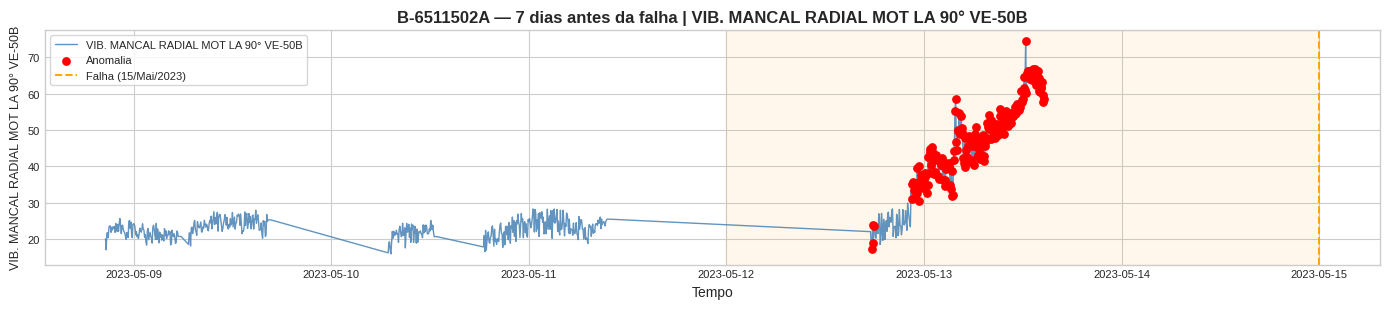

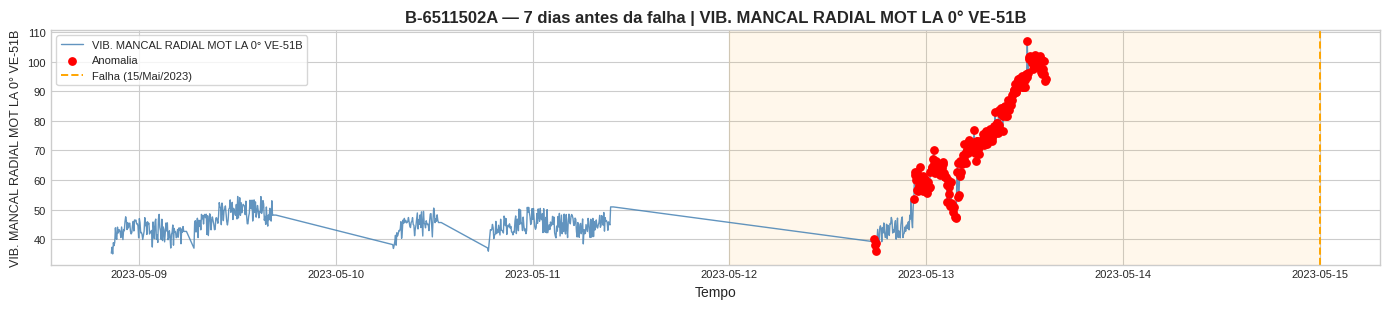

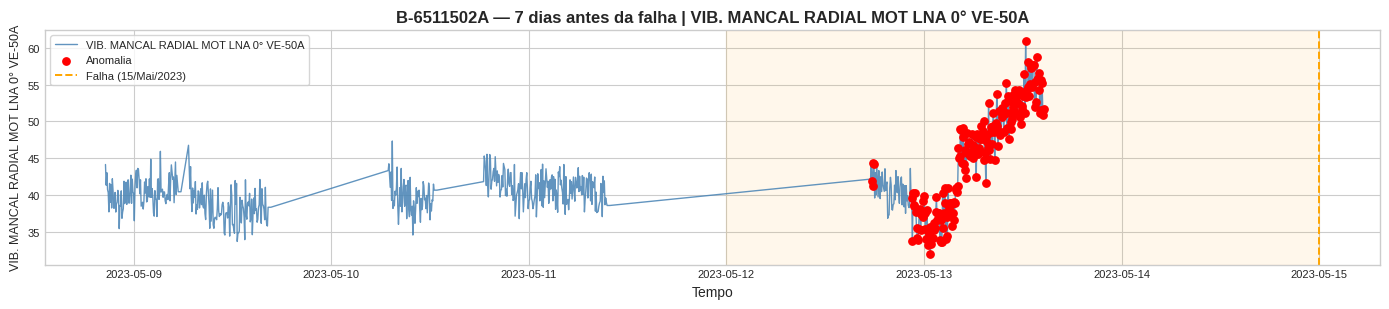

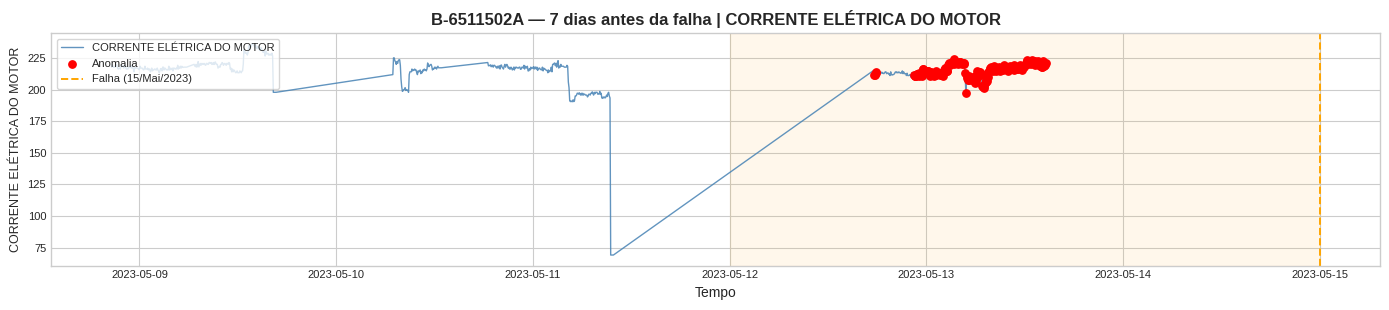

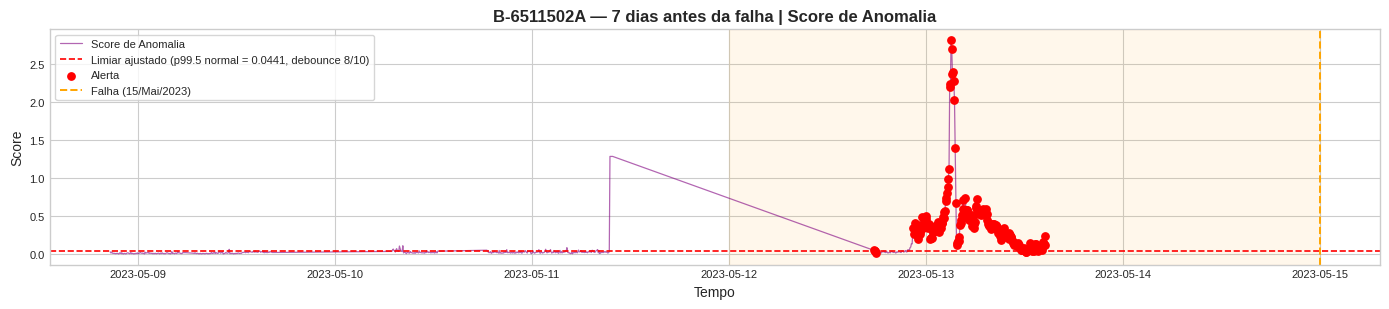

5 PNGs salvos em: /home/chico/Documentos/ciencia-dados/Transpetro-modelos/notebooks/b6511502a/plots
   zoom7d_vib__mancal_radial_mot_la_90__ve_50b.png
   zoom7d_vib__mancal_radial_mot_la_0__ve_51b.png
   zoom7d_vib__mancal_radial_mot_lna_0__ve_50a.png
   zoom7d_corrente_elétrica_do_motor.png
   zoom7d_score.png


In [8]:
# Gráficos SEPARADOS (1 por sensor + 1 do score) — prontos para slides
z = EVENT_TS_F1 - pd.Timedelta(days=7)
dfw = df_base.loc[z:EVENT_TS_F1]; sw = scores.loc[z:EVENT_TS_F1]
common = dfw.index.intersection(sw.index); dfw, sw = dfw.loc[common], sw.loc[common]
sensors = [s for s in KEY_SENSORS if s in dfw.columns]
saved = plot_separated(dfw, sw, sensors, selected_threshold, selected_k, selected_n,
                       EVENT_TS_F1, EVENT_LABEL_F1, PREFAILURE_DAYS,
                       title_prefix=f'{EQUIPMENT_ID} — 7 dias antes da falha',
                       tag='zoom7d', threshold_label=threshold_label,
                       save=SAVE_PLOTS, outdir=OUTPUT_DIR, dpi=OUTPUT_DPI)
if SAVE_PLOTS:
    print(f'{len(saved)} PNGs salvos em: {OUTPUT_DIR}')
    for p in saved: print('  ', p.split('/')[-1])

## Série completa com limiar ajustado

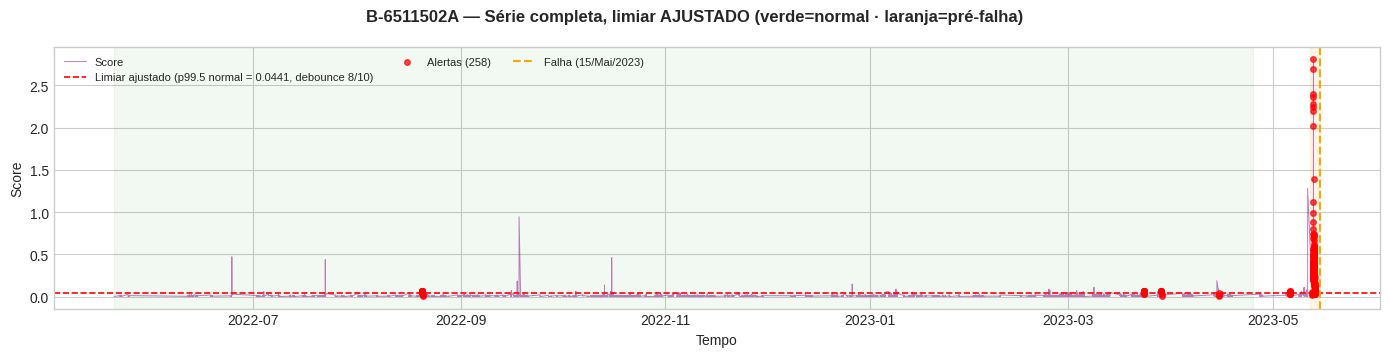

Total de alertas: 258 | FP no período normal: 0.12%
PNG salvo: /home/chico/Documentos/ciencia-dados/Transpetro-modelos/notebooks/b6511502a/plots/serie_completa.png


In [9]:
plt.style.use('seaborn-v0_8-whitegrid')
y = scores['reconstruction_error']
fig, ax = plt.subplots(figsize=(FIGSIZE_WIDTH, 3.6))
ax.plot(scores.index, y, color='purple', linewidth=0.7, alpha=0.5, label='Score')
ax.axhline(selected_threshold, color='red', linestyle='--', linewidth=1.2, label=threshold_label)
idx = scores.index[flags]
ax.scatter(idx, y[idx], s=16, color='red', alpha=0.7, zorder=4, label=f'Alertas ({len(idx)})')
ax.axvspan(scores.index.min(), EVENT_TS_F1-pd.Timedelta(days=NORMAL_END_DAYS), color='green', alpha=0.05)
ax.axvspan(EVENT_TS_F1-pd.Timedelta(days=PREFAILURE_DAYS), EVENT_TS_F1, color='orange', alpha=0.10)
ax.axvline(EVENT_TS_F1, color='orange', linestyle='--', linewidth=1.5, label=EVENT_LABEL_F1)
ax.set_ylabel('Score'); ax.set_xlabel('Tempo'); ax.legend(loc='upper left', fontsize=8, ncol=3)
fig.suptitle(f'{EQUIPMENT_ID} — Série completa, limiar AJUSTADO (verde=normal · laranja=pré-falha)', fontsize=12, fontweight='bold')
fig.tight_layout()
if SAVE_PLOTS:
    from pathlib import Path as _P; _P(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
    fig.savefig(f'{OUTPUT_DIR}/serie_completa.png', dpi=OUTPUT_DPI, bbox_inches='tight')
plt.show()
print(f'Total de alertas: {int(flags.sum())} | FP no período normal: {flags[_mn].mean():.2%}')
if SAVE_PLOTS: print(f'PNG salvo: {OUTPUT_DIR}/serie_completa.png')